In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error ,mean_squared_error,r2_score

In [2]:
df=pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [5]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [6]:
df.describe(include="all")

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
count,4340,4340.000000,4.340000e+03,4340.000000,4340,4340,4340,4340
unique,1491,NaN,NaN,NaN,5,3,2,5
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner
freq,69,NaN,NaN,NaN,2153,3244,3892,2832
mean,NaN,2013.090783,5.041273e+05,66215.777419,NaN,NaN,NaN,NaN
std,NaN,4.215344,5.785487e+05,46644.102194,NaN,NaN,NaN,NaN
min,NaN,1992.000000,2.000000e+04,1.000000,NaN,NaN,NaN,NaN
25%,NaN,2011.000000,2.087498e+05,35000.000000,NaN,NaN,NaN,NaN
50%,NaN,2014.000000,3.500000e+05,60000.000000,NaN,NaN,NaN,NaN
75%,NaN,2016.000000,6.000000e+05,90000.000000,NaN,NaN,NaN,NaN


In [7]:
df["brand"]=df["name"].apply(lambda x : x.split()[0])

In [8]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


In [9]:
df1=df.drop("name",axis=1)

In [10]:
df1.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


we going step by step cleaning columns first we split name to brand and dropped the name 

In [11]:
df.year.max()

np.int64(2020)

In [12]:
df.year.min()

np.int64(1992)

In [13]:
from datetime import datetime

In [14]:
current_year=datetime.now().year

In [15]:
print(current_year)

2026


In [16]:
df1["age"]=current_year-df["year"]

In [17]:
df1.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,age
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


In [18]:
df2=df1.drop("year",axis=1)

In [19]:
df2.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,age
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


In second columns we changed to age by current year - year in that car

In [20]:
df2["km_driven_per_year"]=df2["km_driven"]/df2["age"]

In [21]:
df2.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,age,km_driven_per_year
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19,3684.210526
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19,2631.578947
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14,7142.857143
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9,5111.111111
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12,11750.000000


In [22]:
df2[df2["km_driven_per_year"]==df2.km_driven_per_year.max()]

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,age,km_driven_per_year
525,665000,560000,Diesel,Dealer,Manual,First Owner,Maruti,10,56000.0
4184,665000,560000,Diesel,Dealer,Manual,First Owner,Maruti,10,56000.0


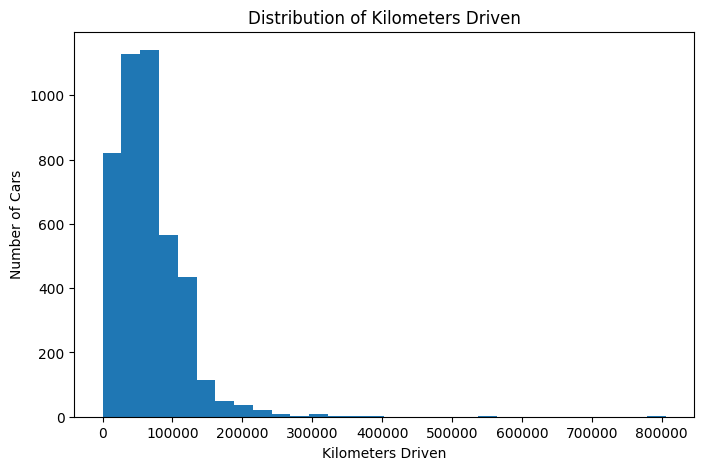

In [23]:

plt.figure(figsize=(8, 5))
plt.hist(df2["km_driven"], bins=30)
plt.title("Distribution of Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Number of Cars")
plt.show()

(array([1.010e+03, 1.802e+03, 1.025e+03, 3.230e+02, 1.050e+02, 4.400e+01,
        1.600e+01, 1.200e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00]),
 array([8.33333333e-02, 2.80007917e+03, 5.60007500e+03, 8.40007083e+03,
        1.12000667e+04, 1.40000625e+04, 1.68000583e+04, 1.96000542e+04,
        2.24000500e+04, 2.52000458e+04, 2.80000417e+04, 3.08000375e+04,
        3.36000333e+04, 3.64000292e+04, 3.92000250e+04, 4.20000208e+04,
        4.48000167e+04, 4.76000125e+04, 5.04000083e+04, 5.32000042e+04,
        5.60000000e+04]),
 <BarContainer object of 20 artists>)

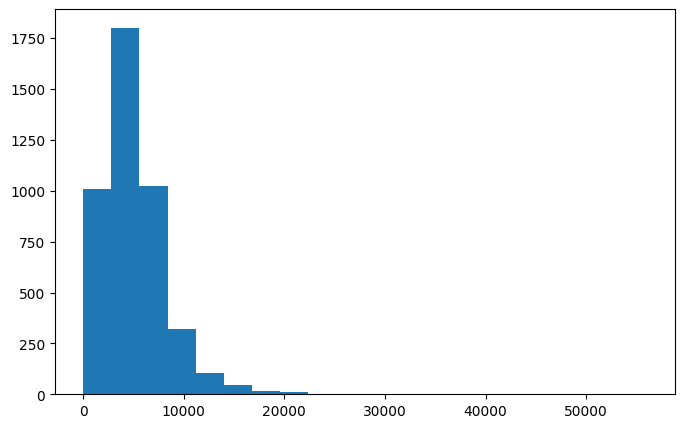

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df2["km_driven_per_year"],bins=20)


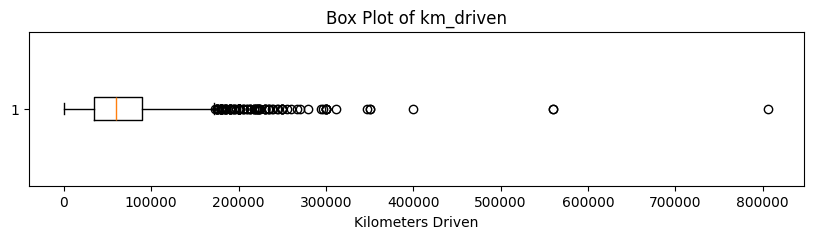

In [25]:


plt.figure(figsize=(10, 2))
plt.boxplot(df2["km_driven"], vert=False)
plt.title("Box Plot of km_driven")
plt.xlabel("Kilometers Driven")
plt.show()

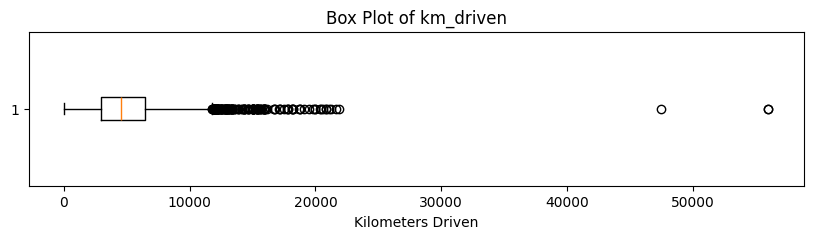

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
plt.boxplot(df2["km_driven_per_year"], vert=False)
plt.title("Box Plot of km_driven")
plt.xlabel("Kilometers Driven")
plt.show()

In [27]:
df2["km_driven_per_year"].describe()

count     4340.000000
mean      5062.744401
std       3294.702096
min          0.083333
25%       2941.176471
50%       4559.027778
75%       6466.800000
max      56000.000000
Name: km_driven_per_year, dtype: float64

In [28]:
df2.sort_values(by="km_driven_per_year", ascending=False)[
    ["brand", "age", "km_driven", "km_driven_per_year"]
].head(10)

,brand,age,km_driven,km_driven_per_year
525,Maruti,10,560000,56000.000000
4184,Maruti,10,560000,56000.000000
1243,Maruti,17,806599,47447.000000
69,Chevrolet,16,350000,21875.000000
3171,Maruti,12,260000,21666.666667
2964,Maruti,14,296823,21201.642857
3675,Mahindra,14,295000,21071.428571
3981,Toyota,12,250000,20833.333333
1674,Volkswagen,15,312000,20800.000000
2394,Toyota,17,350000,20588.235294


In [29]:
df2.duplicated().sum()

np.int64(790)

In [30]:
duplicate_rows = df2[df2.duplicated()]
duplicate_rows.head(10)

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,age,km_driven_per_year
13,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19,3684.210526
14,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19,2631.578947
15,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14,7142.857143
16,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9,5111.111111
17,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12,11750.000000
18,140000,125000,Petrol,Individual,Manual,First Owner,Maruti,19,6578.947368
19,550000,25000,Petrol,Individual,Manual,First Owner,Hyundai,10,2500.000000
20,240000,60000,Petrol,Individual,Manual,Second Owner,Tata,12,5000.000000
21,850000,25000,Petrol,Individual,Manual,First Owner,Hyundai,11,2272.727273
22,365000,78000,CNG,Individual,Manual,First Owner,Maruti,9,8666.666667


In [31]:
print(df2.duplicated().sum())

df2[df2.duplicated(keep=False)].head(20)

790


,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,age,km_driven_per_year
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19,3684.210526
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19,2631.578947
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14,7142.857143
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9,5111.111111
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12,11750.000000
5,140000,125000,Petrol,Individual,Manual,First Owner,Maruti,19,6578.947368
6,550000,25000,Petrol,Individual,Manual,First Owner,Hyundai,10,2500.000000
7,240000,60000,Petrol,Individual,Manual,Second Owner,Tata,12,5000.000000
8,850000,25000,Petrol,Individual,Manual,First Owner,Hyundai,11,2272.727273
9,365000,78000,CNG,Individual,Manual,First Owner,Maruti,9,8666.666667


In [32]:
print("Before:", df2.shape)

df2 = df2.drop_duplicates()

print("After:", df2.shape)

Before: (4340, 9)
After: (3550, 9)


In [33]:
df2.duplicated().sum()

np.int64(0)

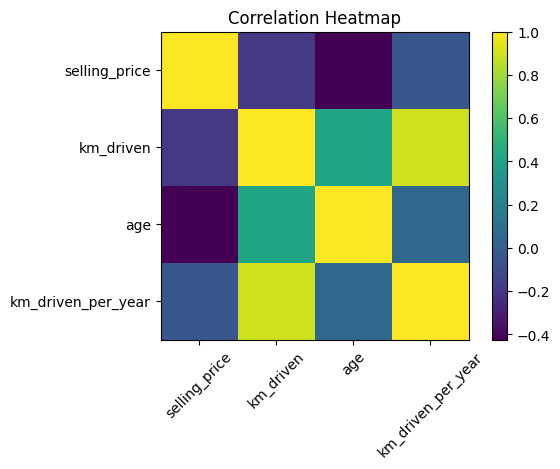

In [34]:


corr = df2[[
    "selling_price",
    "km_driven",
    "age",
    "km_driven_per_year"
]].corr()

plt.figure(figsize=(6, 4))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [35]:
X = df2.drop(["selling_price","km_driven_per_year"], axis=1)
y = df2["selling_price"]

In [36]:
X.select_dtypes(include="str").columns

Index(['fuel', 'seller_type', 'transmission', 'owner', 'brand'], dtype='str')

In [37]:
X = pd.get_dummies(X, drop_first=True)

In [38]:
X.head()

,km_driven,age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,70000,19,False,False,False,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,50000,19,False,False,False,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,100000,14,True,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,46000,9,False,False,False,True,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,141000,12,True,False,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [39]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:


model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
y_pred = model.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2*100)

MAE : 181133.58485339332
RMSE: 357706.9200560869
R²  : 62.10239809951339


In [44]:
df2.to_csv("car_price_cleaned.csv", index=False)